# Fenòmen del món petit

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

from utils import draw_graph, draw_graphs

Definim les funcions per construïr les xarxes

In [35]:
# a) Anell regular
def anell_regular(N, k):
    G = nx.Graph()
    for i in range(N):
        for j in range(1,k//2+1):
            G.add_edge(i,(i + j)%N )
            G.add_edge(i,(i - j)%N )
    return G

# b) Xarxa aleatòria d'Erdős–Rényi
def erdos_renyi(N, k):
    p = k/N # Chance of connection between a pair of nodes
    B = nx.Graph()
    for i in range(N):
        for j in range(N):
            if j != i: # Avoid auto-loops
                if np.random.random() < p: 
                    B.add_edge(i,j)
    return B

# c) Xarxa de Watts–Strogatz
def watts_strogatz(N, k, beta):
    G = anell_regular(N, k) 
    for node in range(N):
        for neighbour in list(G.neighbors(node)): # List won't be modified during the iteration
            if np.random.random() < beta:
                # Rewiring: remove the current edge
                G.remove_edge(node,neighbour)

                # Choose randomly a new neighbour different from the current one
                new_neighbour = np.random.randint(0,N)
                while (new_neighbour == node):
                    new_neighbour = np.random.randint(0,N)

                # Reconnects the node to the new random neighbour
                G.add_edge(node, new_neighbour)
    return G

Funcions per $L$ i $C$

In [36]:
# L = 〈d(i,j)〉(mitjana de les distàncies mínimes entre tots els parells de nodes)
def L(G):
    try:
        return nx.average_shortest_path_length(G)
    except nx.NetworkXError:
        return float('inf')

# C (proporció de triangles tancats sobre el nombre de camins de longitud 2). 
def C(G):
    try:
        return nx.average_clustering(G)
    except nx.NetworkXError:
        return 0

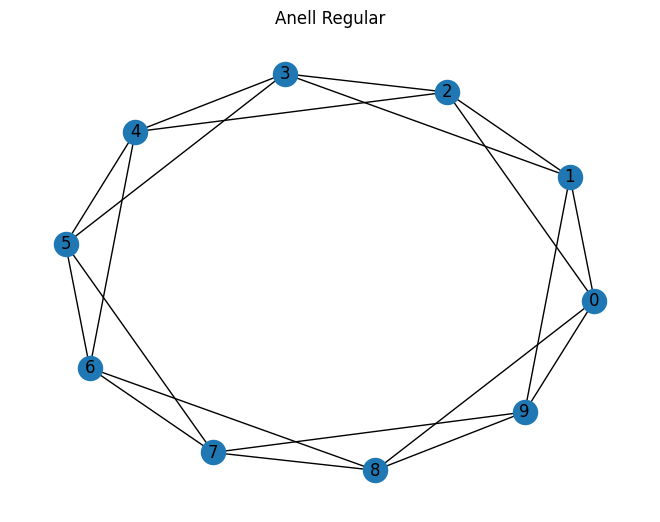

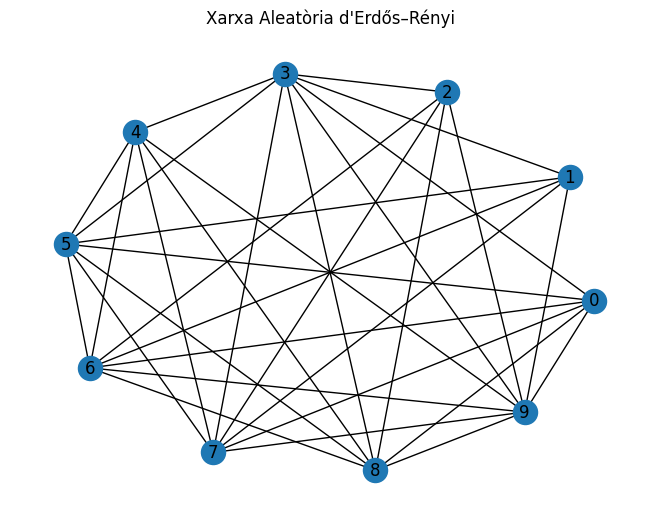

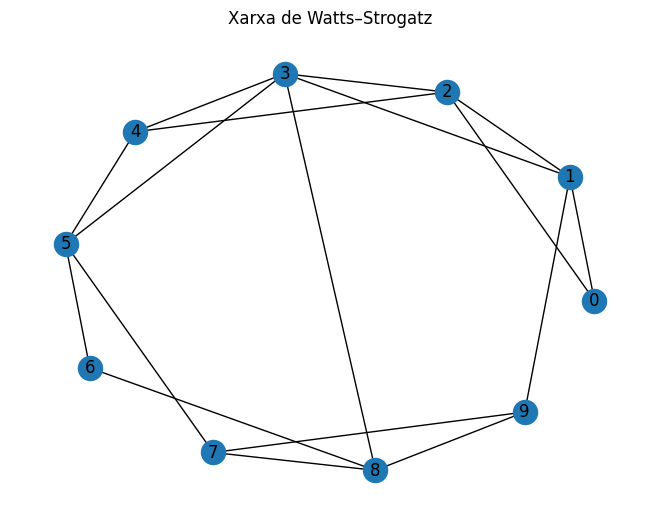

In [37]:
# Exemples d'ús
N = 10
k = 4
beta = 0.3

graphs = {
    "Anell Regular": anell_regular(N, k),
    "Xarxa Aleatòria d'Erdős–Rényi": erdos_renyi(N, k),
    "Xarxa de Watts–Strogatz": watts_strogatz(N, k, beta)
}

# Garanteix que la posició dels nodes sigui la mateixa a cada graf
pos = nx.spring_layout(graphs["Anell Regular"], seed=123)

# draw_graphs(graphs)

draw_graph(graphs["Anell Regular"], "Anell Regular", pos=pos)
draw_graph(graphs["Xarxa Aleatòria d'Erdős–Rényi"], "Xarxa Aleatòria d'Erdős–Rényi", pos=pos)
draw_graph(graphs["Xarxa de Watts–Strogatz"], "Xarxa de Watts–Strogatz", pos=pos)

## Estudi del problema

Estudiar la proporció entre $k$ i $N$  ($k/N$). Mirar si pels valors que ens donen una proporció p tenen els mateixos resultats de $L$ i $C$.

In [38]:
# Com que volem fer moltes simulacions i per xarxes grans, i el càclul de L és molt costós,
# comprovem que una L aproximada per 100 nodes a l'atzar és prou bona
def L_approx(G, n_samples=None):
    """
    Estima el camí mig (L) fent servir un mostreig de nodes font.
    Si n_samples és None, calcula el valor exacte (lent).
    """
    nodes = list(G.nodes())
    N = len(nodes)
    
    # Si la xarxa és petita o no especifiquem mostres, fem el càlcul exacte
    if n_samples is None or n_samples >= N:
        try:
            return nx.average_shortest_path_length(G)
        except (nx.NetworkXError, nx.NetworkXNoPath):
            return float('inf')

    # Triem n_samples nodes a l'atzar com a punts de partida
    sources = random.sample(nodes, n_samples)
    lengths = []

    for source in sources:
        # Calculem les distàncies des de 'source' a TOTS els altres nodes
        # Això és un sol BFS (molt ràpid en xarxes no pesades)
        path_lengths = nx.single_source_shortest_path_length(G, source)
        
        # Ignorem la distància al propi node (que és 0)
        distancies = [v for k, v in path_lengths.items() if k != source]
        lengths.extend(distancies)

    # Si no hem trobat camins (xarxa desconnectada), retornem inf
    if not lengths:
        return float('inf')
        
    return np.mean(lengths)

Considerem que amb `n_samples=50` obtenim una bona aproximació de L. A partir d'ara calculem L amproximant-la amb `L_aprox`.

In [39]:
def prop_study(prop: float, beta: float):
    Ns = range(100, 1001, 20)
    ks = [N*prop for N in Ns]
    Ls = []
    Cs = []
    Ls_norm = []
    Cs_norm = []

    print(f"### Study for prop={prop}, beta={beta} ###")
    for i in range(len(Ns)):
        N = Ns[i]
        k = int(ks[i])
        G0 = anell_regular(N, k)
        L0 = L(G0)
        C0 = C(G0)
        
        if beta != 0:
            G = watts_strogatz(N, k, beta)
            if L0 != 0: # Evitem dividir per zero
                L_norm = L(G)/L0
            else:
                L_norm = float('inf')

            if C0 != 0: # Evitem dividir per zero       
                C_norm = C(G)/C0
            else:
                C_norm = float('inf')
            # print(f"N={N}, k={k}, L_norm={L_norm:.5f}, C_norm={C_norm:.5f}")
            Ls_norm.append(L_norm)
            Cs_norm.append(C_norm)
            Ls.append(L_norm*L0) 
            Cs.append(C_norm*C0)

        else: 
            Ls.append(L0)
            Cs.append(C0)
            Ls_norm.append(1) # L_norm és 1 quan beta=0
            Cs_norm.append(1) # C_norm és 1 quan beta=0
            # print(f"N={N}, k={k}, L={L0:.5f}, C={C0:.5f}")
    
    return Ls, Cs, Ls_norm, Cs_norm

In [40]:
# Estudiem els extrems
Ls_b0, Cs_b0, Ls_norm_b0, Cs_norm_b0 = prop_study(0.1, 0)
Ls_b1, Cs_b1, Ls_norm_b1, Cs_norm_b1 = prop_study(0.1, 1)

### Study for prop=0.1, beta=0 ###
### Study for prop=0.1, beta=1 ###


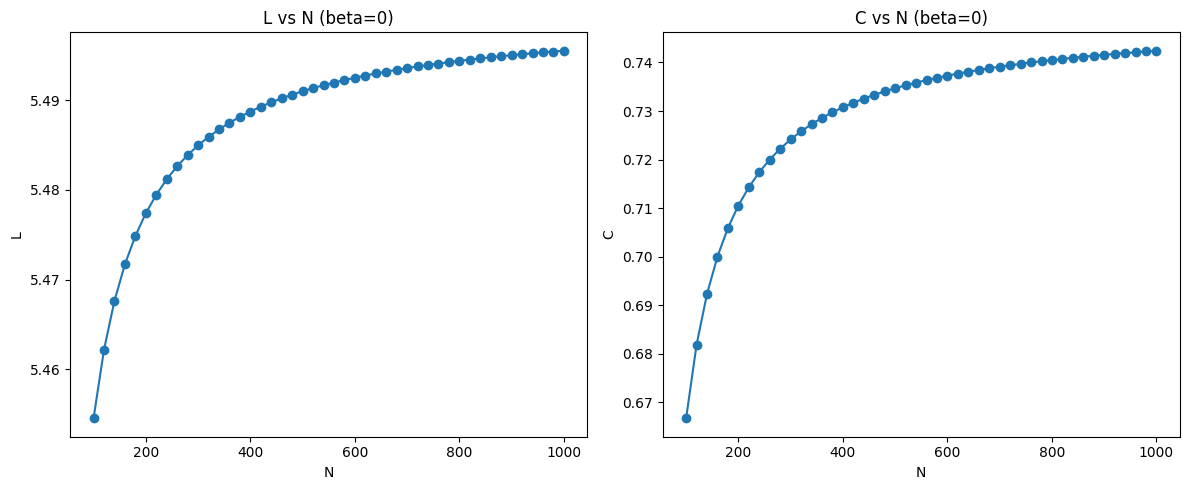

In [41]:
Ns = range(100, 1001, 20)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(Ns, Ls_b0, label='L (beta=0)', marker='o')
plt.xlabel('N')
plt.ylabel('L')
plt.title('L vs N (beta=0)')
plt.subplot(1, 2, 2)
plt.plot(Ns, Cs_b0, label='C (beta=0)', marker='o')
plt.xlabel('N')
plt.ylabel('C')
plt.title('C vs N (beta=0)')
plt.tight_layout()
plt.show()

$\beta=0$ és el nostre punt de referència. 

Tribialment sabem que $L_{norm} = 1$ i $C_{norm} = 1$ (com que estem normalitzant els valors dividint pel valor de la xarxa regular ($L_{norm} = \frac{L(\beta)}{L(0)}$), quan $\beta=0$ estem dividint un número per si mateix).
Això té un significat físic: La xarxa regular té la màxima clusterització (molta estructura local, molts triangles) però també la màxima distància mitjana (és molt ineficient, per creuar la xarxa has de passar node per node en un camí "llarg").

Mirant els valors no normalitzats de $L$ podem veureque si la densitat ($k/N$) es manté fixa, les propietats de la xarxa regular són independents de la seva mida ($N$) a partir d'un cert llindar.
Observem que tant $L$ com $C$ deixen de créixer bruscament i es tornen gairebé plans a partir de $N \approx 400-500$. Podem concloure que una xarxa regular de 500 nodes és "estructuralment idèntica" a una de 1000 nodes si la proporció de veïns és la mateixa. La topologia està definida per la densitat, no pel nombre absolut de nodes.

Veiem que $L$ s'estavilitza al voltant de $5.5$. Per un anell regular, la distància mitjana és aproximadament $L \approx \frac{N}{2k}$. En el nostre exemple, on la proporció és $k/N = 0.1$, $$L \approx \frac{N}{2 \cdot (0.1N)} = \frac{1}{0.2} = 5$$
El gràfic mostra que $L$ convergeix cap a un valor fix (prop de 5.5). Això demostra que, en una xarxa regular, la distància mitjana només depèn de la densitat de connexions. Si cada node coneix el 10% de la xarxa, sempre trigaràs el mateix nombre de salts per arribar a l'altre costat, independentment del nombre de nodes de la xarxa.

Respecte $C$ també podem observar coses interessants: Límit teòric de clusterització.
Veiem que al gràfic de la dreta, els punts tendeixen a un valorproper a $0.75$. No cal buscar gaire per trobar que el coeficient de clusterització teòric en un anell regular se'l pot calcular de la següent manera: $C=\frac{3(k-2)}{4(k-1)}$. Els nostres resultats ho proven. Quan $N$ creix (i per tant $k$ creix, ja que $k = p \cdot N$), el terme $\frac{k-2}{k-1}$ tendeix a $1$. Això explica per què la nostra corba s'apropa asimptòticament a 3/4 (0.75). 

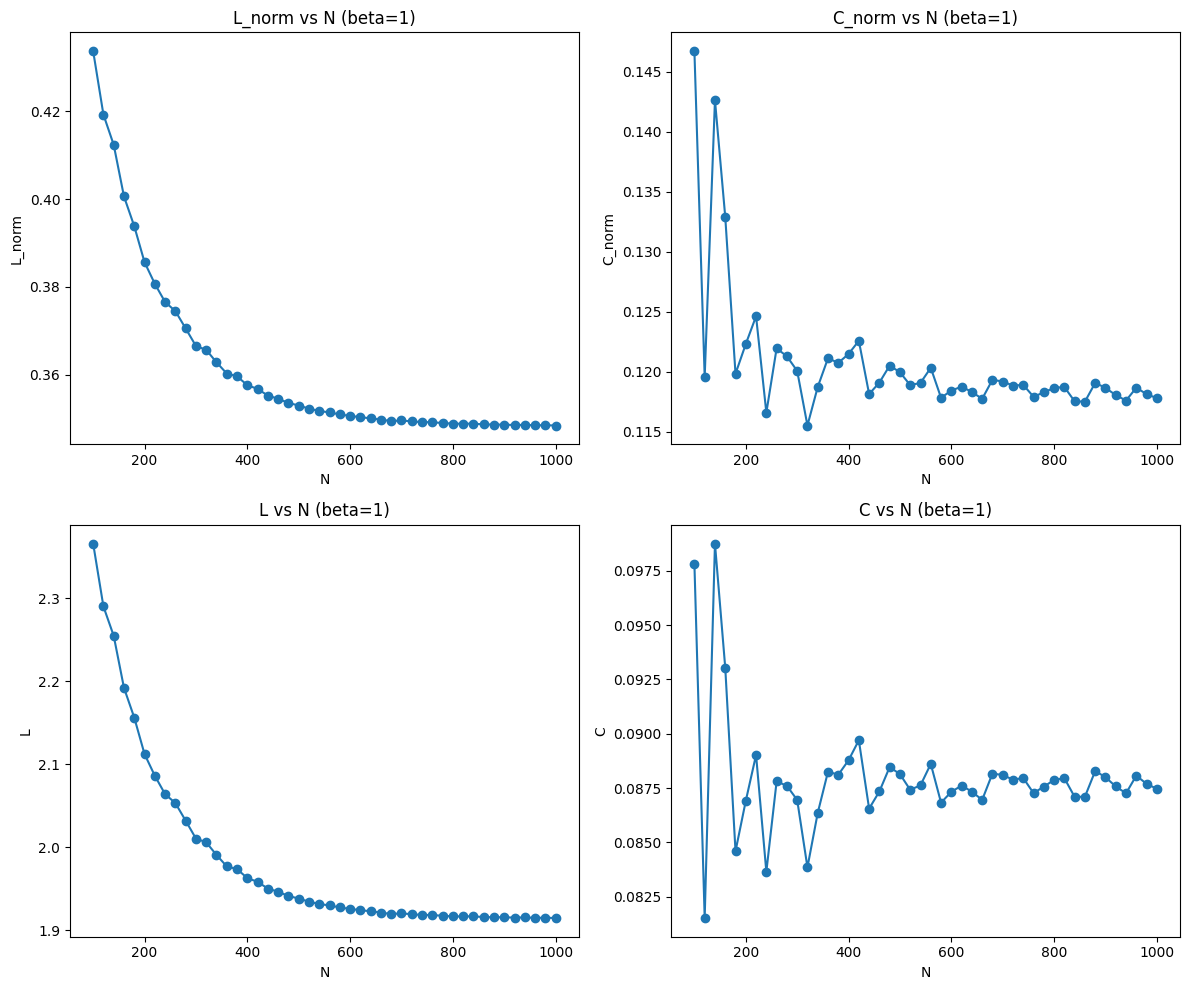

In [43]:
# Estudiem l'altre extrem, beta=1
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(Ns, Ls_norm_b1, label='L_norm (beta=1)', marker='o')
plt.xlabel('N')
plt.ylabel('L_norm')
plt.title('L_norm vs N (beta=1)')
plt.subplot(2, 2, 2)
plt.plot(Ns, Cs_norm_b1, label='C_norm (beta=1)', marker='o')
plt.xlabel('N')
plt.ylabel('C_norm')
plt.title('C_norm vs N (beta=1)')

plt.subplot(2, 2, 3)
plt.plot(Ns, Ls_b1, label='L (beta=1)', marker='o')
plt.xlabel('N')
plt.ylabel('L')
plt.title('L vs N (beta=1)')
plt.subplot(2, 2, 4)
plt.plot(Ns, Cs_b1, label='C (beta=1)', marker='o')
plt.xlabel('N')
plt.ylabel('C')
plt.title('C vs N (beta=1)')
plt.tight_layout()
plt.show()

Mentre que els gràfics de $\beta=0$ ens deien com és la "base", aquests ens diuen exactament com de millor (o pitjor) és una xarxa aleatòria respecte a la regular quan el sistema es fa gran.

$L$ i $C$ respecte la xarxa regular (normalització):
+ El gràfic de dalt a l'esquerra mostra que $L_{norm}$ baixa de $0.43$ a $0.35$ i després s'estabilitza.
    
    Això significa que a mesura que $N$ creix, la xarxa aleatòria es torna proporcionalment més eficient que la regular. Amb 100 nodes, la distància és un 43% de la original; amb 1.000 nodes, només un 35%. Això ho podriem explicar perquè en un anell regular, per anar a l'altre costat has de fer un "passeig" seqüencial. En canvi, a la xarxa aleatòria ($\beta=1$), apareixen dreceres que connecten punts oposats del cercle. A mesura que el sistema creix, l'impacte d'aquestes dreceres sobre la mitjana total és cada cop més potent fins a arribar a un límit definit per la densitat ($k/N$).

+ El gràfic de dalt a la dreta és molt interessant pel "soroll" inicial (oscil·lacions en $N < 400$).
    
    Per a valors petits de $N$, la xarxa aleatòria és molt sensible a l'atzar. Una aresta més o una menys canvia molt la proporció de triangles (hi ha una variancia alta a les mostres petites). A partir de $N=600$, la corba s'estabilitza al voltant de $0.118$. Això ens ajuda a demostrar el que sospitàvem: la ràtio de clusterització entre una xarxa aleatòria i una regular només depèn de la densitat ($k/N$). Una vegada la xarxa és prou gran, la mida ja no importa; la xarxa aleatòria sempre tindrà aproximadament un 12% de la clusterització que tindria la regular.


$L$ i $C$ d'una xarxa aleatòria:
+ El gràfic de baix a l'esquerra mostra que el camí mig baixa (de 2.35 a 1.9 aproximadament) a mesura que la xarxa es fa gran.

    Normalment, en fer una xarxa més gran, la distància creix. Però aquí estem mantenint la proporció $k/N$ constant. Això vol dir que, a mesura que $N$ puja, el nombre de veïns ($k$) també puja. Podriem concloure que en una xarxa aleatòria, l'augment del nombre de veïns per node té molt més impacte que l'augment del nombre total de nodes. L'atzar aprofita tan bé les noves connexions que, encara que hi hagi més nodes on anar, el caminant arriba més ràpid a tot arreu.

    Comparant-ho amb la xarxa regular on $L$ es quedava clavada en 5.5. Aquí, a $\beta=1$, la $L$ és molt més baixa (~2) i a sobre decreix. Això demostra que l'atzar és un connector **exponencialment més potent** que la proximitat física.


In [ ]:
# TODO: Ara ho estudiem per a diferents valors de beta
betas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

Fixant N i K, però variant $\beta$, per veure com afecta a L i C

In [32]:
# Fixem una N prou gran i fem algunes simulacions per veure com varien L i L_approx
N = 2000
k = int(0.05 * N) 
betes = [10**(-k) for k in range(10, -1, -1)]

Ls = []
L_approxs = []
Cs = []

n_samples = 50


G0 = anell_regular(N, k)
L0 = L_approx(G0, n_samples=n_samples)
C0 = C(G0)

for beta in betes:
    G = watts_strogatz(N, k, beta)

    Ls.append(L(G))
    L_approxs.append(L_approx(G, n_samples=n_samples)/L0)
    Cs.append(C(G)/C0)


plt.figure(figsize=(8,5))
plt.plot(betes, L_approxs, marker='o', label='L', color='red')
plt.plot(betes, Cs, marker='o', label='C', color='blue')
plt.xscale('log')
plt.xlabel('beta')
plt.ylabel('L (vermell) i C (blau)')
plt.title(f'L i C vs beta (N={N}, k={k})')
plt.legend()
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Coses que podriem fer:
+ Calcular $L(\beta)$ i $C(\beta)$ per als valors de $\beta$ que tenim i normalitzar-los.
    + Representar-ho en un gràfic amb eix $x$ logarítmc. Ens hauria de sortir que L cau en picat mentre C es manté alt.
    + Reflexió: Per què unes poques "dreceres" tenen un impacte tan massiu en la distància mitjana però gairebé no afecten a la clusterització local?

+ Calcular `mixing_time` per a cada valor de beta.
    + Hipòtesi: En un anell regular el temps és molt alt (perquè està atrapat localment). A mida que s'augmenta $\beta$, hauria de decreixer similarment a L.
    + Comprovar si el "col·lapse" del temps de mescla coincideix amb l'aparició del fenòmen del mon petit. Això demostraria que aquest tipus de xarxes no només són curtes en distància, sinó també eficients per a processos de difusió.

+ Fixant un $\beta$ baix i variant N, comparar com creix el temps de cobertura en l'anell regular en comparació a la xarxa del mon petit.
    + Hauriem de veure que en l'anell regular el temps de cobertura creix de forma quadràtica i que en una aleatòria, molt més ràpidament $\approx N\log N$.
    + Mirar que fa la xarxa de Watts-Strogatz.

+ Visualització de la Distribució estacionària.
    + A la xarxa Erdos-renyi els graus no son iguals, fer histograma de la probabilitat estacionària de cada node.
    + Dibuixar el graf de manera que el color o mida del node depengui del seu valor a la distribució estàcionària.
    + Podem identificar els nodes centrals que actuen "com a imants" per al camí aleatori.

+ Què passa si la xarxa no és connexa?



Sembla que fer el graf dirigit complica molt les cose si hauriem de modificar moltes funcions. Si fos el cas que ho fessim, podriem mirar el següent:
+ El `cover_time` es bloquejarà fàcilment en simulació. Estudiar a mida que augmentem $\beta$ aquest bloqueig.
+ `stacionari_distribution` deixaria de funcionar, i el problema es convertiriaen l'algorisme de PageRank de Google.
+ Com calculem L? Ara el camí de A a B té longitud diferent al de B a A.